# Statistical Tests
ทดสอบว่าความแตกต่างของตัวแปรระหว่างกลุ่ม `Churned = 0` และ `Churned = 1` มีนัยสำคัญทางสถิติหรือไม่ โดยอ้างอิงจาก feature importance

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu

palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
level_order = ['Strong', 'Moderate', 'Weak', 'None']
alpha = 0.05

sns.set_theme(style='whitegrid')

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')
df_importance = pd.read_csv('../../../Data/processed/feature_importance.csv', keep_default_na=False)
df_importance['importance_level'] = pd.Categorical(
    df_importance['importance_level'],
    categories=level_order,
    ordered=True
)
df_importance = df_importance.sort_values(['importance_level', 'importance'], ascending=[True, False]).reset_index(drop=True)

def run_mannwhitney(feature):
    group_0 = df.loc[df['Churned'] == 0, feature].dropna()
    group_1 = df.loc[df['Churned'] == 1, feature].dropna()
    statistic, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')
    return {
        'feature': feature,
        'importance': df_importance.loc[df_importance['feature'] == feature, 'importance'].iloc[0],
        'importance_level': df_importance.loc[df_importance['feature'] == feature, 'importance_level'].iloc[0],
        'median_non_churn': group_0.median(),
        'median_churn': group_1.median(),
        'median_gap': group_1.median() - group_0.median(),
        'u_statistic': statistic,
        'p_value': p_value,
        'significant': p_value < alpha
    }

def build_test_results():
    numeric_features = [feature for feature in df_importance['feature'].tolist() if feature in df.columns]
    results = pd.DataFrame([run_mannwhitney(feature) for feature in numeric_features])
    results['neg_log10_p'] = -np.log10(results['p_value'].clip(lower=1e-300))
    return results.sort_values(['significant', 'importance'], ascending=[False, False]).reset_index(drop=True)

def summarize_significance(results):
    summary = (
        results.groupby(['importance_level', 'significant'], observed=False)
        .size()
        .reset_index(name='feature_count')
    )
    full_index = pd.MultiIndex.from_product(
        [level_order, [True, False]],
        names=['importance_level', 'significant']
    )
    summary = (
        summary.set_index(['importance_level', 'significant'])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )
    return summary

test_results = build_test_results()

## Test Design
ใช้ Mann-Whitney U test กับทุก feature เชิงตัวเลขเพื่อทดสอบความแตกต่างระหว่างกลุ่ม churn และ non-churn โดยไม่สมมติการแจกแจงแบบปกติ

,importance_level,significant,feature_count
0,Strong,True,6
1,Strong,False,0
2,Moderate,True,5
3,Moderate,False,0
4,Weak,True,5
5,Weak,False,0
6,None,True,3
7,None,False,2


,feature,importance_level,importance,median_non_churn,median_churn,median_gap,u_statistic,p_value,significant
0,Lifetime_Value,Strong,0.1290,1266.79,1132.73,-134.06,274943119.0,3.9057e-35,True
1,Customer_Service_Calls,Strong,0.1279,5.00,7.00,2.00,159747427.0,0.0000e+00,True
2,Cart_Abandonment_Rate,Strong,0.0991,55.50,66.60,11.10,165419115.5,0.0000e+00,True
3,Discount_Usage_Rate,Strong,0.0715,40.20,38.60,-1.60,283200056.5,1.4742e-72,True
4,Age,Strong,0.0685,37.00,36.00,-1.00,289261494.0,6.9603e-109,True
5,Days_Since_Last_Purchase,Strong,0.0609,21.00,24.00,3.00,214430640.5,5.8460e-185,True
6,Total_Purchases,Moderate,0.0556,13.00,10.00,-3.00,318323441.0,0.0000e+00,True
7,Email_Open_Rate,Moderate,0.0473,21.10,14.90,-6.20,330636760.0,0.0000e+00,True
8,Average_Order_Value,Moderate,0.0473,108.94,124.40,15.46,207205180.0,2.2416e-252,True
9,Session_Duration_Avg,Moderate,0.0408,27.40,23.60,-3.80,328757165.5,0.0000e+00,True


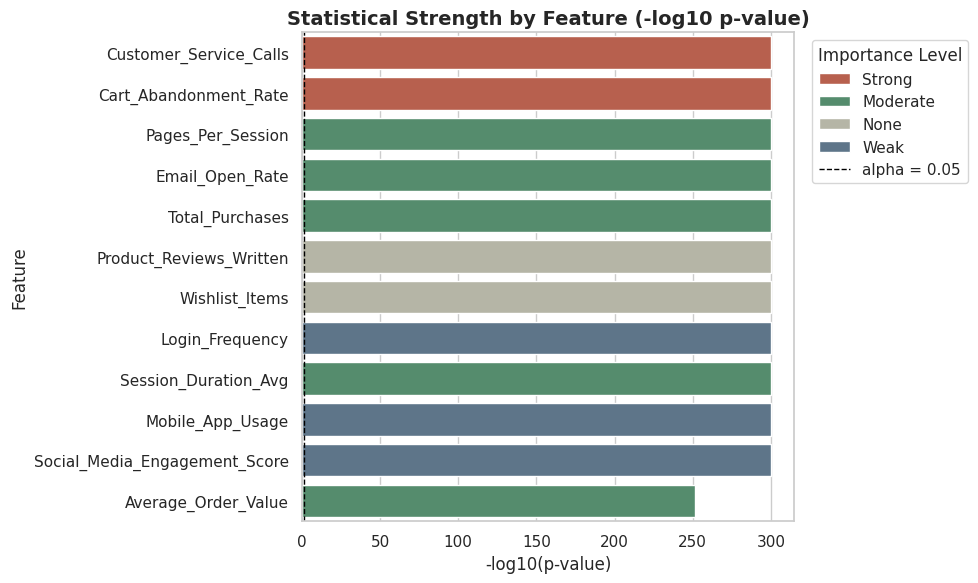

In [6]:
summary_significance = summarize_significance(test_results)
summary_significance_display = summary_significance.copy()
display(summary_significance_display)

display(
    test_results.assign(
        importance=test_results['importance'].round(4),
        median_non_churn=test_results['median_non_churn'].round(2),
        median_churn=test_results['median_churn'].round(2),
        median_gap=test_results['median_gap'].round(2),
        p_value=test_results['p_value'].map(lambda value: f'{value:.4e}')
    )[['feature', 'importance_level', 'importance', 'median_non_churn', 'median_churn', 'median_gap', 'u_statistic', 'p_value', 'significant']]
)

plt.figure(figsize=(10, 6))
plot_results = test_results.sort_values('neg_log10_p', ascending=False).head(12)
sns.barplot(
    data=plot_results,
    y='feature',
    x='neg_log10_p',
    hue='importance_level',
    dodge=False,
    palette=palette_level
)
plt.axvline(-np.log10(alpha), color='black', linestyle='--', linewidth=1, label='alpha = 0.05')
plt.title('Statistical Strength by Feature (-log10 p-value)', fontsize=14, weight='bold')
plt.xlabel('-log10(p-value)')
plt.ylabel('Feature')
plt.legend(title='Importance Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Significant Features
ดูเฉพาะ feature ที่มีนัยสำคัญทางสถิติ เพื่อแยกว่าอะไรเป็นสัญญาณจริงและอะไรเป็น noise

## Interpretation Guide
- `significant = True` หมายถึง distribution ของ feature นั้นต่างกันระหว่าง churn และ non-churn อย่างมีนัยสำคัญ
- ถ้า importance สูงและ p-value ต่ำมาก แปลว่า feature นั้นทั้งสำคัญต่อโมเดลและต่างกันจริงในข้อมูล
- ถ้า importance ต่ำและไม่ significant มักเป็นตัวแปรที่ไม่จำเป็นต้องเน้นใน insight หลัก

In [4]:
significant_results = test_results.loc[test_results['significant']].copy()
insignificant_results = test_results.loc[~test_results['significant']].copy()

display(
    significant_results.assign(
        importance=significant_results['importance'].round(4),
        median_gap=significant_results['median_gap'].round(2),
        p_value=significant_results['p_value'].map(lambda value: f'{value:.4e}')
    )[['feature', 'importance_level', 'importance', 'median_gap', 'p_value']]
)

display(
    insignificant_results.assign(
        importance=insignificant_results['importance'].round(4),
        median_gap=insignificant_results['median_gap'].round(2),
        p_value=insignificant_results['p_value'].map(lambda value: f'{value:.4e}')
    )[['feature', 'importance_level', 'importance', 'median_gap', 'p_value']]
)

,feature,importance_level,importance,median_gap,p_value
0,Lifetime_Value,Strong,0.1290,-134.06,3.9057e-35
1,Customer_Service_Calls,Strong,0.1279,2.00,0.0000e+00
2,Cart_Abandonment_Rate,Strong,0.0991,11.10,0.0000e+00
3,Discount_Usage_Rate,Strong,0.0715,-1.60,1.4742e-72
4,Age,Strong,0.0685,-1.00,6.9603e-109
5,Days_Since_Last_Purchase,Strong,0.0609,3.00,5.8460e-185
6,Total_Purchases,Moderate,0.0556,-3.00,0.0000e+00
7,Email_Open_Rate,Moderate,0.0473,-6.20,0.0000e+00
8,Average_Order_Value,Moderate,0.0473,15.46,2.2416e-252
9,Session_Duration_Avg,Moderate,0.0408,-3.80,0.0000e+00


,feature,importance_level,importance,median_gap,p_value
19,Membership_Years,NaN,0.0215,0.0,7.9677e-01
20,Payment_Method_Diversity,NaN,0.0092,0.0,4.4986e-01
